# Train a tram forecast and create a November–December submission

This notebook trains and validates a model, then can refit it on January–October
and write forecasts for all 61 days of November and December. A 61-day validation
run measures WAPE on the observed September–October holdout. The November–December
actual labels are withheld, so the final submission itself cannot be scored locally.

Run cells in order. Preparation needs complete local raw CSVs and labels. No data,
weights, or executed outputs are embedded in this notebook.

Install the package with the `notebook` extra, select that environment as your
Jupyter kernel, and restart the kernel after changing PyTorch. See the repository
README for installation commands.


In [1]:
import json
import os
import sys
from dataclasses import replace
from pathlib import Path

# Works when Jupyter starts at the repository root or inside notebooks/.
ROOT = next(
    (path for path in (Path.cwd(), *Path.cwd().parents)
     if (path / 'src/tram_forecast').is_dir() and (path / 'pyproject.toml').is_file()),
    None,
)
if ROOT is None:
    raise RuntimeError('Start Jupyter inside the tram forecasting repository.')
os.chdir(ROOT)

import matplotlib.pyplot as plt
import numpy as np
import torch
from IPython.display import display

from tram_forecast.checkpoint import load_model
from tram_forecast.dataset import ForecastDataset
from tram_forecast.evaluate import evaluate_model, fixed_forecast, metric_report, weekly_profile
from tram_forecast.io import write_json
from tram_forecast.preprocess import prepare
from tram_forecast.settings import Settings
from tram_forecast.smoke import smoke
from tram_forecast.storage import Store
from tram_forecast.train import train

print('Repository:', ROOT)
print('Kernel Python:', sys.executable)
print('PyTorch:', torch.__version__, '| Wheel CUDA runtime:', torch.version.cuda)
print('CUDA available:', torch.cuda.is_available())
if torch.cuda.is_available():
    print('GPU:', torch.cuda.get_device_name(0))

Repository: /home/unicorn/trans_predicting
Kernel Python: /home/unicorn/trans_predicting/.venv/bin/python
PyTorch: 2.14.0+cu126 | Wheel CUDA runtime: 12.6
CUDA available: True
GPU: NVIDIA GeForce GTX 1080


## Configure the run

`BATCH_SIZE` counts contexts. Each context has up to `FORECAST_DAYS` targets;
near the fitting boundary the group is shorter. Gradients are weighted by the
number of requested days. `ACCUMULATION=8` combines eight context microbatches.

Use `FORECAST_DAYS = 61` to validate across September 1–October 31 and to prepare
a model for the full November–December horizon. Validation freezes history at
September 1; it does not update history with observed days during the 61-day holdout.
Choose a new `RUN_NAME` for each experiment. To resume an interrupted run, set
`RESUME` to that run's `latest.pt`.


In [ ]:
MODEL_KIND = 'full'  # 'full' adds raw-event processing (boarding_only other)
FORECAST_DAYS = 61
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
EPOCHS = 100
BATCH_SIZE = 60
ACCUMULATION = 1
RUN_NAME = f'{MODEL_KIND}_{FORECAST_DAYS}days_v6'
RESUME = None                # Example: 'outputs/notebook_runs/boarding_only_61days_v2/latest.pt'

base = Settings.load(ROOT / 'configs/default.json')
settings = replace(
    base,
    training=replace(
        base.training,
        forecast_days=FORECAST_DAYS,
        device=DEVICE,
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        accumulation=ACCUMULATION,
    ),
)
if MODEL_KIND not in ('boarding_only', 'full'):
    raise ValueError('MODEL_KIND must be boarding_only or full.')
if DEVICE.startswith('cuda') and not torch.cuda.is_available():
    raise RuntimeError('CUDA requested but unavailable; check the wheel, driver and kernel.')

# Edit settings.data paths above if your dataset lives outside this repository.
ARTIFACT = Path(settings.data.output_root) / 'validation'
RUN_DIR = Path(RESUME).resolve().parent if RESUME else ROOT / 'outputs/notebook_runs' / RUN_NAME
print('Model:', MODEL_KIND, '| Horizon:', FORECAST_DAYS, '| Device:', DEVICE)
print('Artifact:', ARTIFACT, '| Run:', RUN_DIR)
display(settings.to_dict())


Model: full | Horizon: 61 | Device: cuda
Artifact: outputs/prepared/validation | Run: /home/unicorn/trans_predicting/outputs/notebook_runs/full_61days_v5


{'model': {'embedding_dims': (4, 4, 8, 4, 8),
  'category_caps': (32, 128, 512, 32, 8192),
  'min_frequency': 5,
  'event1': ((12, 3, 1), (12, 5, 1), (8, 3, 2)),
  'event2': ((12, 3, 1), (12, 5, 2), (8, 3, 4)),
  'hourly': ((12, 3, 1), (12, 5, 24), (8, 3, 168)),
  'shared1': ((24, 3, 1), (24, 5, 2), (16, 3, 12)),
  'shared2': ((12, 3, 1), (12, 5, 2), (8, 3, 12)),
  'shared3': ((6, 3, 1), (6, 5, 2), (4, 3, 6)),
  'history_days': 21,
  'event_depth': 2,
  'shared_depth': 3,
  'event_pool': 'max',
  'temporal_pool': 'max',
  'pooled_hours': None,
  'head_width': 250,
  'max_hours': 32,
  'max_positions': 32768,
  'checkpoint_events': True,
  'dropout': 0.1,
  'seed': 67},
 'data': {'raw_paths': ('dataset/train.csv', 'dataset/test.csv'),
  'label_paths': ('dataset/labels/labels_day_train.csv',
   'dataset/labels/labels_day_test.csv'),
  'routes': (1, 7, 11, 12, 17, 25, 26, 28, 50),
  'start': '2025-01-01',
  'validation_cutoff': '2025-09-01',
  'final_cutoff': '2025-11-01',
  'forecast_end

## Prepare or reuse the validation artifact

Preparation validates CSVs, fits vocabularies/scaling only on January–August,
and sorts raw events on disk. For a 61-day horizon the validation report uses
observed September–October labels. Preparation may take time on the full dataset.
Identical inputs reuse an existing artifact; changed inputs require a new artifact
path. Use complete source CSVs; preparation rejects truncated or malformed rows.


In [3]:
missing = [path for path in (*settings.data.raw_paths, *settings.data.label_paths)
           if not Path(path).is_file()]
if missing:
    raise FileNotFoundError('Missing dataset files: ' + ', '.join(missing))
ARTIFACT = prepare(settings, 'validation', ARTIFACT)
dataset = ForecastDataset(ARTIFACT, MODEL_KIND, settings.training.forecast_days)
store = dataset.store
print('Training contexts:', len(dataset))
print('First context:', dataset[0]['identity'])
print('First target group:', dataset[0]['target'].shape)
print('Raw/label mismatched hours:', store.metadata['raw_label_mismatched_hours'])

Training contexts: 1998
First context: SampleIdentity(route=1, cutoff=datetime.date(2025, 1, 22), requested=datetime.date(2025, 1, 22))
First target group: (61, 24)
Raw/label mismatched hours: 0


## Weekly-profile baseline and resource check

The baseline averages the three matching weekday/hour observations in the fixed
21-day history. It predicts the same horizon as the neural model. WAPE is lower
when forecasts are better. The smoke check runs forward/backward for typical and
busiest contexts, without an optimizer step. Reduce batch or event chunk budgets
if memory is insufficient; keep all events.

In [4]:
from datetime import date

available_days = (date.fromisoformat(store.metadata['evaluation_end']) - store.end).days
if settings.training.forecast_days > available_days:
    raise ValueError('Requested horizon exceeds the available validation period.')
actual = np.asarray(store.evaluation_targets()).reshape(len(store.routes) + 1, available_days, 24)
actual = actual[:, :settings.training.forecast_days]
baseline_prediction = weekly_profile(store, settings.training.forecast_days)
baseline_report = metric_report(actual[:-1], baseline_prediction, store.routes)
display(baseline_report['global'])

{'wape': 0.1962989319008062,
 'wape_score': 0.8037010680991938,
 'absolute_error': 2503690.9972491264,
 'actual_total': 12754481.0,
 'mae': 190.0190495787133,
 'positions': 13176,
 'undefined_reason': None}

In [5]:
resource_report = smoke(settings, ARTIFACT, MODEL_KIND)
display(resource_report)

{'checks': [{'case': 'typical',
   'route': 1,
   'cutoff': '2025-04-29',
   'seconds': 0.7476763089998713,
   'process_peak_rss_bytes': 1676029952,
   'cuda_peak_allocated_bytes': 67259392,
   'cuda_peak_reserved_bytes': 98566144},
  {'case': 'busiest',
   'route': 17,
   'cutoff': '2025-03-25',
   'seconds': 0.5599295619995246,
   'process_peak_rss_bytes': 1761554432,
   'cuda_peak_allocated_bytes': 105854464,
   'cuda_peak_reserved_bytes': 140509184}],
 'parameters': {'events': 10664,
  'raw': 4592,
  'boarding': 872,
  'shared': 25072,
  'route': 80,
  'head': 177524,
  'total': 218804},
 'artifact': '2ce7fbe16ce8e2bcc1b2a2fe6b7831c6c873f6742e661e95e25d09a66e1f76a2',
 'optimizer_steps': 0,
 'batch_size_tested': 1,
 'forecast_days': 61}

## Train

This cell runs training and prints one summary per epoch. Checkpoints, resolved
configuration and `history.json` are saved in `RUN_DIR`. Validation uses the same
fixed context at every epoch. The lowest validation WAPE selects `best.pt`.

To continue after interruption, set `RESUME` in the configuration cell and rerun
from there. Epoch-boundary resume reruns an interrupted partial epoch. A fresh
run refuses to overwrite existing checkpoints.

In [6]:
best_checkpoint = train(
    settings, ARTIFACT, model_kind=MODEL_KIND, output=RUN_DIR, resume=RESUME,
)
print('Selected checkpoint:', best_checkpoint)

ValueError: run already exists; use --resume or a new output directory

## Learning curves

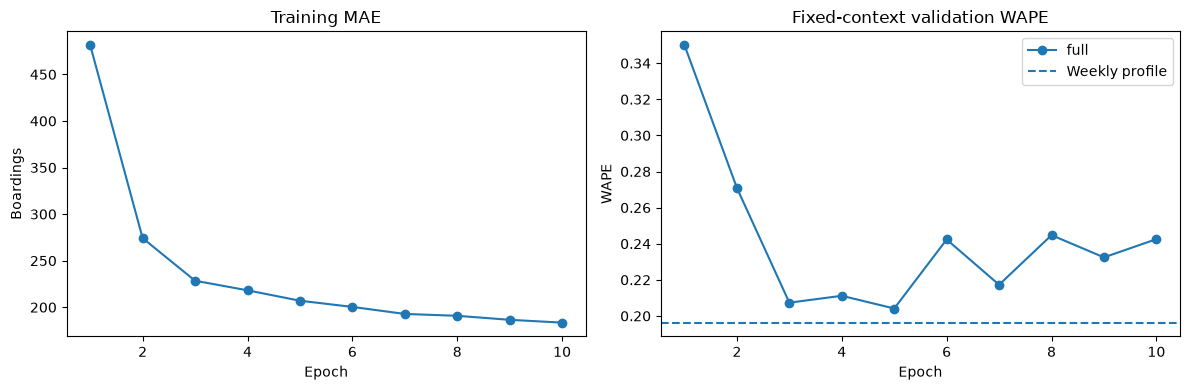

In [ ]:
history = json.loads((RUN_DIR / 'history.json').read_text())
epochs = [row['epoch'] for row in history]
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(epochs, [row['mae'] for row in history], marker='o')
axes[0].set(title='Training MAE', xlabel='Epoch', ylabel='Boardings')
axes[1].plot(epochs, [row['validation']['neural']['global']['wape'] for row in history], marker='o', label=MODEL_KIND)
if baseline_report['global']['wape'] is not None:
    axes[1].axhline(baseline_report['global']['wape'], linestyle='--', label='Weekly profile')
axes[1].set(title='Fixed-context validation WAPE', xlabel='Epoch', ylabel='WAPE')
axes[1].legend()
fig.tight_layout()
plt.show()

## Evaluate the best checkpoint on September–October

The horizon comes from the saved checkpoint. With `FORECAST_DAYS = 61`, these
metrics compare the forecast from a fixed September 1 cutoff against observed
September–October labels. This is the local holdout score used to select a model;
it is not the eventual November–December competition score.


In [ ]:
model, payload = load_model(best_checkpoint, store, settings.training.device)
checkpoint_days = payload['settings']['training']['forecast_days']
report = evaluate_model(model, store, checkpoint_days)
write_json(RUN_DIR / 'evaluation.json', report)
display({
    'horizon_days': report['forecast_days'],
    'neural': report['neural']['global'],
    'weekly_profile': report['weekly_profile']['global'],
    'including_route5': report['full_grid_with_route5']['global'],
})

{'horizon_days': 61,
 'neural': {'wape': 0.204115544757483,
  'wape_score': 0.795884455242517,
  'absolute_error': 2603387.8374139667,
  'actual_total': 12754481.0,
  'mae': 197.585597860805,
  'positions': 13176,
  'undefined_reason': None},
 'weekly_profile': {'wape': 0.1962989319008062,
  'wape_score': 0.8037010680991938,
  'absolute_error': 2503690.9972491264,
  'actual_total': 12754481.0,
  'mae': 190.0190495787133,
  'positions': 13176,
  'undefined_reason': None},
 'including_route5': {'wape': 0.204115544757483,
  'wape_score': 0.795884455242517,
  'absolute_error': 2603387.8374139667,
  'actual_total': 12754481.0,
  'mae': 177.8270380747245,
  'positions': 14640,
  'undefined_reason': None}}

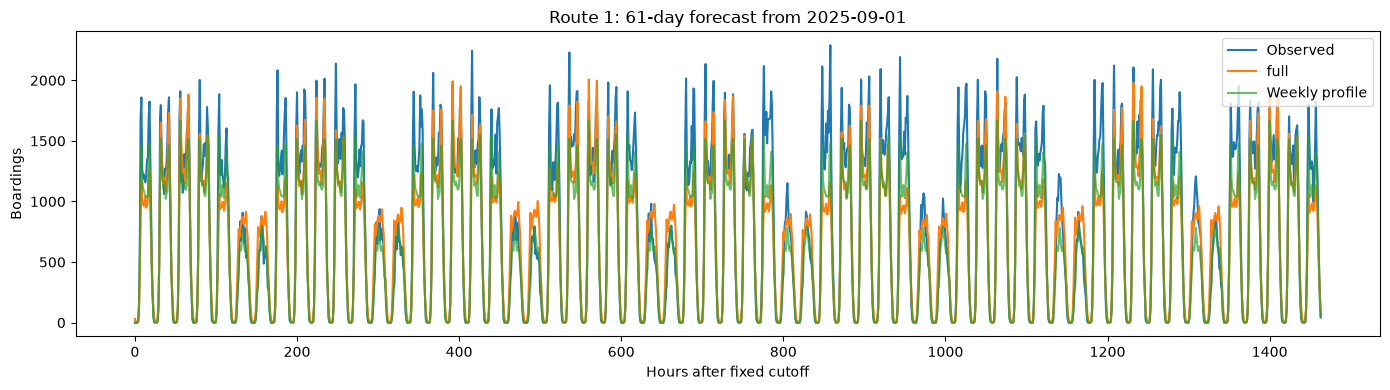

In [ ]:
ROUTE_TO_PLOT = store.routes[0]
route_index = store.routes.index(ROUTE_TO_PLOT)
prediction = fixed_forecast(model, store, checkpoint_days)
hours = np.arange(checkpoint_days * 24)
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(hours, actual[route_index, :checkpoint_days].reshape(-1), label='Observed')
ax.plot(hours, prediction[route_index].reshape(-1), label=MODEL_KIND)
ax.plot(hours, baseline_prediction[route_index, :checkpoint_days].reshape(-1), label='Weekly profile', alpha=0.7)
ax.set(title=f'Route {ROUTE_TO_PLOT}: {checkpoint_days}-day forecast from {store.end}',
       xlabel='Hours after fixed cutoff', ylabel='Boardings')
ax.legend()
fig.tight_layout()
plt.show()

## Benchmark forecast speed

This benchmark uses the selected validation checkpoint and one route at the fixed
September 1 cutoff. It reports first-touch and repeated context loading, a 61-day
forecast when the raw context is already loaded, the prediction head with an
already encoded context, and end-to-end context loading plus forecast. Timings
include CUDA work (the benchmark synchronizes before and after each measurement).

Repeated reads usually use the operating system's file cache. “First-touch” is the
first read in this notebook cell, not a guaranteed cold-disk measurement. Report
median and p95 latency; compare runs on the same device and under similar load.
The final October context may have a different event volume, so treat this as a
validation-period speed estimate.


In [ ]:
import time
from datetime import timedelta

from tram_forecast.dataset import collate_samples, history_sample
from tram_forecast.schema import SampleIdentity, request_calendar

BENCH_ROUTE = 1
BENCH_REPEATS = 10
BENCH_DAYS = 61

bench_store = store
DEVICE = 'cpu'
bench_model = model.to(DEVICE)
bench_model.eval()
bench_device = torch.device(DEVICE)
bench_dates = [bench_store.end + timedelta(days=i) for i in range(BENCH_DAYS)]
bench_leads = np.arange(1, BENCH_DAYS + 1, dtype=np.float32)


def load_benchmark_context():
    sample = history_sample(
        bench_store,
        SampleIdentity(BENCH_ROUTE, bench_store.end, bench_store.end),
        MODEL_KIND == 'full',
    )
    sample['lead'] = bench_leads
    sample['request_calendar'] = request_calendar(bench_dates)
    history, request, _ = collate_samples([sample], DEVICE)
    return history, request


def sync_benchmark_device():
    if bench_device.type == 'cuda':
        torch.cuda.synchronize(bench_device)


def benchmark_ms(function, repeats=BENCH_REPEATS, warmups=1):
    with torch.inference_mode():
        for _ in range(warmups):
            function()
            sync_benchmark_device()
        samples = []
        for _ in range(repeats):
            sync_benchmark_device()
            started = time.perf_counter()
            function()
            sync_benchmark_device()
            samples.append((time.perf_counter() - started) * 1000)
    return {
        'median_ms': float(np.percentile(samples, 50)),
        'p95_ms': float(np.percentile(samples, 95)),
        'mean_ms': float(np.mean(samples)),
    }


sync_benchmark_device()
started = time.perf_counter()
bench_history, bench_request = load_benchmark_context()
sync_benchmark_device()
first_touch_load_ms = (time.perf_counter() - started) * 1000

with torch.inference_mode():
    bench_encoded = bench_model.encode_history(bench_history)
    sync_benchmark_device()


def predict_with_loaded_context():
    return bench_model(bench_history, bench_request)


def predict_with_preencoded_context():
    return bench_model.predict_day(
        bench_encoded.expand(BENCH_DAYS, -1),
        bench_request['route_indices'],
        bench_request['calendar'],
        bench_request['lead'],
    )


def load_and_predict():
    history, request = load_benchmark_context()
    return bench_model(history, request)


load_stats = benchmark_ms(load_benchmark_context)
loaded_context_stats = benchmark_ms(predict_with_loaded_context)
preencoded_stats = benchmark_ms(predict_with_preencoded_context)
end_to_end_stats = benchmark_ms(load_and_predict)

benchmark_report = {
    'device': DEVICE,
    'model_kind': MODEL_KIND,
    'route': BENCH_ROUTE,
    'days_per_forecast': BENCH_DAYS,
    'hourly_values_per_forecast': BENCH_DAYS * 24,
    'first_touch_context_load_ms_cache_state_uncontrolled': first_touch_load_ms,
    'repeated_context_load': load_stats,
    'forecast_with_context_loaded_encode_plus_head': loaded_context_stats,
    'forecast_with_context_preencoded_head_only': preencoded_stats,
    'end_to_end_context_load_plus_forecast': end_to_end_stats,
    'end_to_end_hourly_values_per_second': (
        BENCH_DAYS * 24 / (end_to_end_stats['median_ms'] / 1000)
    ),
}
display(benchmark_report)


{'device': 'cpu',
 'model_kind': 'boarding_only',
 'route': 1,
 'days_per_forecast': 61,
 'hourly_values_per_forecast': 1464,
 'first_touch_context_load_ms_cache_state_uncontrolled': 1.5278629998647375,
 'repeated_context_load': {'median_ms': 1.1353930003679125,
  'p95_ms': 1.7009443996357725,
  'mean_ms': 1.2017695999929856},
 'forecast_with_context_loaded_encode_plus_head': {'median_ms': 1.7416030000276805,
  'p95_ms': 1.8270511000537226,
  'mean_ms': 1.74638500002402},
 'forecast_with_context_preencoded_head_only': {'median_ms': 0.2248969999527617,
  'p95_ms': 0.3014107499438978,
  'mean_ms': 0.2447548999953142},
 'end_to_end_context_load_plus_forecast': {'median_ms': 2.6655949995983974,
  'p95_ms': 3.9631047997318087,
  'mean_ms': 2.978469399840833},
 'end_to_end_hourly_values_per_second': 549220.7181588232}

### Forecast speed · CPU

**61 days · 1,464 hourly predictions · route 1 · boarding_only**

Whole-horizon latency: **2.67 ms** · Throughput: **549,221 hourly values/s**

| Measurement | Median (ms) | p95 (ms) | Mean (ms) |
| :--- | ---: | ---: | ---: |
| Load context | 1.135 | 1.701 | 1.202 |
| Encode + forecast | 1.742 | 1.827 | 1.746 |
| Forecast with cached encoding | 0.225 | 0.301 | 0.245 |
| End-to-end | 2.666 | 3.963 | 2.978 |

First context load: 1.528 ms (cache state uncontrolled). Repeated stages are timed independently; they are not additive. 10 measured runs per stage after one warm-up. Checkpoint loading and file export are excluded.

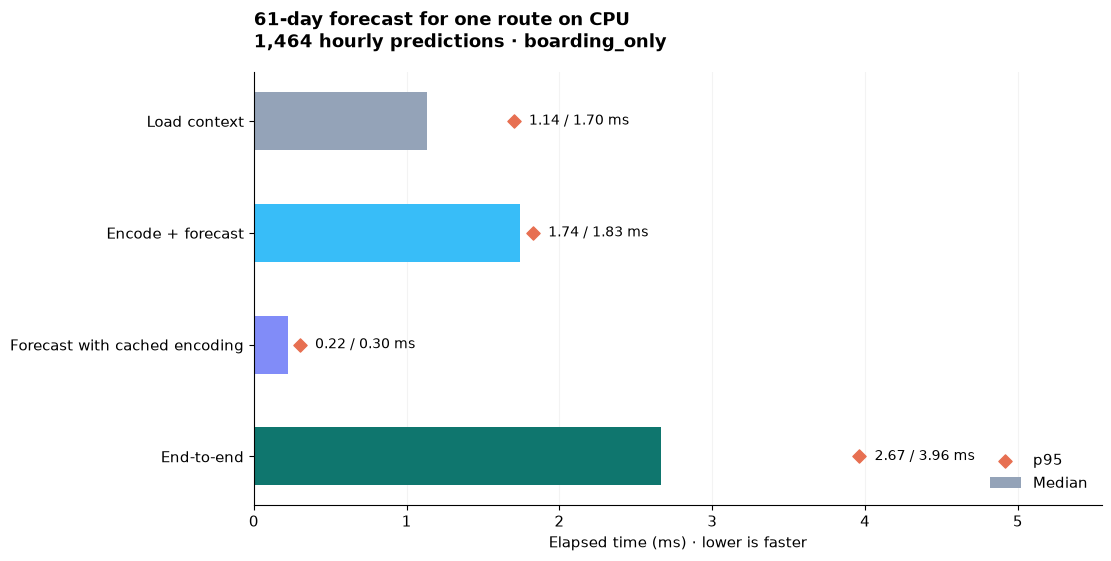

Chart and report saved to /home/unicorn/trans_predicting/outputs/notebook_runs/boarding_only_61days_v5/benchmarks


In [ ]:
from IPython.display import Markdown

# Every forecast timing below covers the entire horizon for ONE route.
r = benchmark_report
stages = [
    ('Load context', 'repeated_context_load'),
    ('Encode + forecast', 'forecast_with_context_loaded_encode_plus_head'),
    ('Forecast with cached encoding', 'forecast_with_context_preencoded_head_only'),
    ('End-to-end', 'end_to_end_context_load_plus_forecast'),
]
medians = np.array([r[key]['median_ms'] for _, key in stages])
p95 = np.array([r[key]['p95_ms'] for _, key in stages])
end_ms = r['end_to_end_context_load_plus_forecast']['median_ms']
summary = (
    f"### Forecast speed · {str(r['device']).upper()}\n\n"
    f"**{r['days_per_forecast']} days · {r['hourly_values_per_forecast']:,} hourly predictions "
    f"· route {r['route']} · {r['model_kind']}**\n\n"
    f"Whole-horizon latency: **{end_ms:.2f} ms** · "
    f"Throughput: **{r['end_to_end_hourly_values_per_second']:,.0f} hourly values/s**\n\n"
    "| Measurement | Median (ms) | p95 (ms) | Mean (ms) |\n"
    "| :--- | ---: | ---: | ---: |\n"
)
for label, key in stages:
    stats = r[key]
    summary += f"| {label} | {stats['median_ms']:.3f} | {stats['p95_ms']:.3f} | {stats['mean_ms']:.3f} |\n"
summary += (
    f"\nFirst context load: {r['first_touch_context_load_ms_cache_state_uncontrolled']:.3f} ms "
    "(cache state uncontrolled). Repeated stages are timed independently; they are not additive. "
    f"{BENCH_REPEATS} measured runs per stage after one warm-up. "
    "Checkpoint loading and file export are excluded."
)
display(Markdown(summary))

with plt.rc_context({'font.size': 11, 'axes.spines.top': False, 'axes.spines.right': False}):
    fig, ax = plt.subplots(figsize=(11, 5.5), layout='constrained')
    y = np.arange(len(stages))
    ax.barh(y, medians, height=0.52, color=['#94a3b8', '#38bdf8', '#818cf8', '#0f766e'], label='Median')
    ax.scatter(p95, y, color='#e76f51', marker='D', s=45, zorder=3, label='p95')
    for index, (median, tail) in enumerate(zip(medians, p95)):
        ax.text(max(median, tail) + max(p95.max(), 0.001) * 0.025, index,
                f'{median:.2f} / {tail:.2f} ms', va='center', fontsize=10)
    ax.set_yticks(y, [label for label, _ in stages])
    ax.invert_yaxis()
    ax.set_xlim(0, max(p95.max(), 0.001) * 1.4)
    ax.set_xlabel('Elapsed time (ms) · lower is faster')
    ax.set_title(
        f"{r['days_per_forecast']}-day forecast for one route on {str(r['device']).upper()}\n"
        f"{r['hourly_values_per_forecast']:,} hourly predictions · {r['model_kind']}",
        loc='left', fontweight='bold', pad=18,
    )
    ax.set_axisbelow(True)
    ax.grid(axis='x', alpha=0.15)
    ax.legend(loc='lower right', frameon=False)
    export_dir = RUN_DIR / 'benchmarks'
    export_dir.mkdir(parents=True, exist_ok=True)
    export_stem = export_dir / f"forecast_speed_{str(r['device']).replace(':', '_')}"
    fig.savefig(export_stem.with_suffix('.png'), dpi=200, bbox_inches='tight')
    fig.savefig(export_stem.with_suffix('.svg'), bbox_inches='tight')
    plt.show()
export_stem.with_suffix('.md').write_text(summary, encoding='utf-8')
export_stem.with_suffix('.json').write_text(json.dumps(r, indent=2), encoding='utf-8')
print(f'Chart and report saved to {export_dir}')


## Refit on January–October and export November–December forecasts

After reviewing the September–October validation WAPE, run these cells to train
fresh weights on all January–October observations and create the full 14,640-row
submission. The final fit uses the **number of completed validation epochs** as its
epoch count (for example, 21 if early stopping completed epoch 21), then trains
from scratch on the expanded January–October data. The lowest-WAPE checkpoint is
used to select the model and epoch count; the refit does not reuse its weights.

Make sure `dataset/train.csv` is the complete January–August file before building
the final artifact. November–December labels are withheld, so the final export
cannot be scored locally; validation metrics above are the available estimate.


In [ ]:
from tram_forecast.predict import predict
from tram_forecast.train import refit

if FORECAST_DAYS != 61:
    raise ValueError('Set FORECAST_DAYS = 61, then rerun the notebook before final refitting.')

FINAL_ARTIFACT = Path(settings.data.output_root) / 'final'
FINAL_RUN_DIR = ROOT / 'outputs/notebook_runs' / f'{RUN_NAME}_final'
FINAL_SUBMISSION = ROOT / 'outputs' / f'{MODEL_KIND}_nov_dec_submission.csv'
validation_history = json.loads((RUN_DIR / 'history.json').read_text())
FINAL_EPOCHS = len(validation_history)
if FINAL_EPOCHS < 1:
    raise ValueError('Validation history contains no completed epochs.')
print('Final refit epochs from validation run:', FINAL_EPOCHS)

FINAL_ARTIFACT = prepare(settings, 'final', FINAL_ARTIFACT)
final_checkpoint = refit(
    best_checkpoint,
    FINAL_ARTIFACT,
    output=FINAL_RUN_DIR,
    device=DEVICE,
    epochs=FINAL_EPOCHS-3,
)
print('Final checkpoint:', final_checkpoint)

written = predict(
    final_checkpoint,
    FINAL_ARTIFACT,
    ROOT / 'dataset/test_submission.csv',
    FINAL_SUBMISSION,
    device=DEVICE,
)
print('Submission:', written)
with open(written, encoding='utf-8') as submission_file:
    row_count = sum(1 for _ in submission_file) - 1
print('Rows:', row_count)
print('Final November–December WAPE: unavailable until actual labels are released.')


Final refit epochs from validation run: 21
Epoch 1: MAE=539.183, WAPE=not evaluated
Epoch 2: MAE=314.484, WAPE=not evaluated
Epoch 3: MAE=254.207, WAPE=not evaluated
Epoch 4: MAE=229.934, WAPE=not evaluated
Epoch 5: MAE=216.486, WAPE=not evaluated
Epoch 6: MAE=208.323, WAPE=not evaluated
Epoch 7: MAE=203.402, WAPE=not evaluated
Epoch 8: MAE=200.437, WAPE=not evaluated
Epoch 9: MAE=197.683, WAPE=not evaluated
Epoch 10: MAE=193.352, WAPE=not evaluated
Epoch 11: MAE=189.89, WAPE=not evaluated
Epoch 12: MAE=186.97, WAPE=not evaluated
Epoch 13: MAE=185.263, WAPE=not evaluated
Epoch 14: MAE=180.815, WAPE=not evaluated
Epoch 15: MAE=175.612, WAPE=not evaluated
Epoch 16: MAE=168.078, WAPE=not evaluated
Epoch 17: MAE=160.562, WAPE=not evaluated
Epoch 18: MAE=155.025, WAPE=not evaluated
Final checkpoint: /home/unicorn/trans_predicting/outputs/notebook_runs/boarding_only_61days_v5_final/final.pt
Submission: /home/unicorn/trans_predicting/outputs/boarding_only_nov_dec_submission.csv
Rows: 14640
Fi

In [ ]:
written = predict(
    final_checkpoint,
    FINAL_ARTIFACT,
    ROOT / 'dataset/test_submission.csv',
    FINAL_SUBMISSION,
    device=DEVICE,
)
print('Submission:', written)
with open(written, encoding='utf-8') as submission_file:
    row_count = sum(1 for _ in submission_file) - 1
print('Rows:', row_count)
print('Final November–December WAPE: unavailable until actual labels are released.')

## Next steps

- Compare `boarding_only` and `full` with the same 61-day horizon and validation artifact.
- Use the lowest validation WAPE checkpoint for final refitting below.
- The final November–December actual labels are withheld. The final forecast CSV can
  be submitted, but its WAPE cannot be calculated locally without those actuals.

This notebook calls the package's training code so checkpointing, loss weighting,
and evaluation behavior stay consistent with the CLI.
